# Blink Abnormality detect using ANN

In [12]:
import tensorflow as tf
from tensorflow import keras
import matplotlib.pyplot as plt
%matplotlib inline
import numpy as np
import seaborn as sns
import pandas as pd


In [13]:
data=pd.read_csv("blink.csv")
data.head()

,AF3,AF4,F3,F4,F7,F8,FC5,FC6,T7,T8,P7,P8,O1,O2,eyeDetection
0,4329.23,4393.85,4289.23,4280.51,4009.23,4635.90,4148.21,4211.28,4350.26,4238.46,4586.15,4222.05,4096.92,4641.03,0
1,4324.62,4384.10,4293.85,4279.49,4004.62,4632.82,4148.72,4207.69,4342.05,4226.67,4586.67,4210.77,4097.44,4638.97,0
2,4327.69,4389.23,4295.38,4282.05,4006.67,4628.72,4156.41,4206.67,4336.92,4222.05,4583.59,4207.69,4096.92,4630.26,0
3,4328.72,4396.41,4296.41,4287.69,4011.79,4632.31,4155.90,4210.77,4343.59,4235.38,4582.56,4217.44,4097.44,4630.77,0
4,4326.15,4398.46,4292.31,4288.21,4011.79,4632.82,4151.28,4212.82,4347.69,4244.10,4586.67,4210.77,4095.90,4627.69,0


In [3]:
data.isna().sum()
data.dropna()

,YearStart,YearEnd,LocationAbbr,LocationDesc,DataSource,Topic,Category,Question,Response,Age,...,QuestionID,ResponseID,DataValueTypeID,AgeID,GenderID,RaceEthnicityID,RiskFactorID,RiskFactorResponseID,GeoLocation,Geographic Level


In [4]:
data.describe()

,YearStart,YearEnd,Data_Value,Low_Confidence_Limit,High_Confidence_Limit,Numerator,Sample_Size,LocationID,DataValueTypeID,GeoLocation,Geographic Level
count,71649.000000,71649.000000,33154.000000,33154.000000,33154.000000,0.0,53859.000000,71649.0,0.0,0.0,0.0
mean,2015.673910,2016.673910,19.585614,17.347588,22.136642,NaN,2463.380401,59.0,NaN,NaN,NaN
std,0.738818,0.738818,30.037798,28.422199,31.424559,NaN,5538.926770,0.0,NaN,NaN,NaN
min,2014.000000,2015.000000,0.000000,0.000000,0.000000,NaN,30.000000,59.0,NaN,NaN,NaN
25%,2016.000000,2017.000000,0.500000,0.140000,1.310000,NaN,130.000000,59.0,NaN,NaN,NaN
50%,2016.000000,2017.000000,3.200000,2.180000,4.930000,NaN,477.000000,59.0,NaN,NaN,NaN
75%,2016.000000,2017.000000,22.087500,16.700000,28.940000,NaN,2008.000000,59.0,NaN,NaN,NaN
max,2016.000000,2017.000000,100.000000,98.570000,100.000000,NaN,70332.000000,59.0,NaN,NaN,NaN


In [5]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 71649 entries, 0 to 71648
Data columns (total 36 columns):
 #   Column                      Non-Null Count  Dtype  
---  ------                      --------------  -----  
 0   YearStart                   71649 non-null  int64  
 1   YearEnd                     71649 non-null  int64  
 2   LocationAbbr                71649 non-null  object 
 3   LocationDesc                71649 non-null  object 
 4   DataSource                  71649 non-null  object 
 5   Topic                       71649 non-null  object 
 6   Category                    71649 non-null  object 
 7   Question                    71649 non-null  object 
 8   Response                    71649 non-null  object 
 9   Age                         71649 non-null  object 
 10  Gender                      71649 non-null  object 
 11  RaceEthnicity               71649 non-null  object 
 12  RiskFactor                  71649 non-null  object 
 13  RiskFactorResponse          716

In [6]:
data.dtypes

YearStart                       int64
YearEnd                         int64
LocationAbbr                   object
LocationDesc                   object
DataSource                     object
Topic                          object
Category                       object
Question                       object
Response                       object
Age                            object
Gender                         object
RaceEthnicity                  object
RiskFactor                     object
RiskFactorResponse             object
Data_Value_Unit                object
Data_Value_Type                object
Data_Value                    float64
Data_Value_Footnote_Symbol     object
Data_Value_Footnote            object
Low_Confidence_Limit          float64
High_Confidence_Limit         float64
Numerator                     float64
Sample_Size                   float64
LocationID                      int64
TopicID                        object
CategoryID                     object
QuestionID  

In [7]:
data=data.drop_duplicates()
data

,YearStart,YearEnd,LocationAbbr,LocationDesc,DataSource,Topic,Category,Question,Response,Age,...,QuestionID,ResponseID,DataValueTypeID,AgeID,GenderID,RaceEthnicityID,RiskFactorID,RiskFactorResponseID,GeoLocation,Geographic Level
0,2016,2017,US,National,NHIS,Service Utilization,Cataract Surgery,Percentage of people with diagnosed cataract w...,Yes,65-84 years,...,QCATS,RYES,NaN,AGE6584,GF,ASN,RFDM,RFBD,NaN,NaN
1,2016,2017,US,National,NHIS,Service Utilization,Cataract Surgery,Percentage of people with diagnosed cataract w...,Yes,85 years and older,...,QCATS,RYES,NaN,AGE85PLUS,GM,OTH,RFDM,RFNO,NaN,NaN
2,2016,2017,US,National,NHIS,Service Utilization,Eye Protection,Proportion of adults who participate in activi...,Refused,40-64 years,...,ISPROT,RRF,NaN,AGE4064,GALL,OTH,RFDM,RFYES,NaN,NaN
3,2016,2017,US,National,NHIS,Service Utilization,Eye Protection,Proportion of adults who participate in activi...,Don't Know,40-64 years,...,ISPROT,RDK,NaN,AGE4064,GM,ALLRACE,RFDM,RFYES,NaN,NaN
4,2016,2017,US,National,NHIS,Service Utilization,Eye Protection,Proportion of adults who participate in activi...,Some of the time,18-39 years,...,ISPROT,RSOMT,NaN,AGE1839,GM,ASN,RFDM,RFNO,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
71644,2016,2017,US,National,NHIS,Visual Function,Visual Field,Percentage of adults who even when wearing gla...,Refused,40-64 years,...,ISNS2,RRF,NaN,AGE4064,GALL,ASN,RFAPAR,RFTOT,NaN,NaN
71645,2016,2017,US,National,NHIS,Visual Function,Visual Field,Percentage of adults who even when wearing gla...,Somewhat difficult,18 years and older,...,ISNS2,RSWD,NaN,AGE18PLUS,GF,ALLRACE,RFAPAR,RFTOT,NaN,NaN
71646,2016,2017,US,National,NHIS,Visual Function,Visual Field,Percentage of adults who even when wearing gla...,Not at all difficult,18-39 years,...,ISNS2,RNOTD,NaN,AGE1839,GF,ALLRACE,RFSM,RFFORM,NaN,NaN
71647,2016,2017,US,National,NHIS,Visual Function,Visual Field,Percentage of adults who even when wearing gla...,Not at all difficult,18-39 years,...,ISNS2,RNOTD,NaN,AGE1839,GF,HISP,RFDM,RFYES,NaN,NaN


<Figure size 1000x800 with 0 Axes>

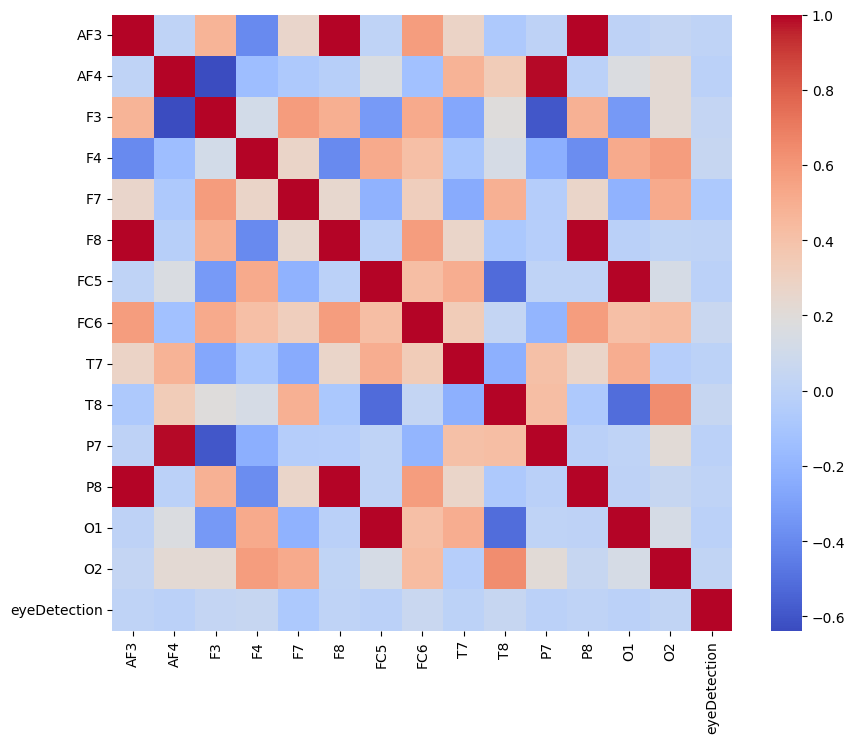

In [10]:
plt.figure(figsize=(10,8))
sns.heatmap(data.corr(),cmap='coolwarm')
plt.show()

In [ ]:
x=data.drop("eyeDetection",axis=1)
y=data["eyeDetection"]

In [20]:
x.head(5)

,AF3,AF4,F3,F4,F7,F8,FC5,FC6,T7,T8,P7,P8,O1,O2
0,4329.23,4393.85,4289.23,4280.51,4009.23,4635.90,4148.21,4211.28,4350.26,4238.46,4586.15,4222.05,4096.92,4641.03
1,4324.62,4384.10,4293.85,4279.49,4004.62,4632.82,4148.72,4207.69,4342.05,4226.67,4586.67,4210.77,4097.44,4638.97
2,4327.69,4389.23,4295.38,4282.05,4006.67,4628.72,4156.41,4206.67,4336.92,4222.05,4583.59,4207.69,4096.92,4630.26
3,4328.72,4396.41,4296.41,4287.69,4011.79,4632.31,4155.90,4210.77,4343.59,4235.38,4582.56,4217.44,4097.44,4630.77
4,4326.15,4398.46,4292.31,4288.21,4011.79,4632.82,4151.28,4212.82,4347.69,4244.10,4586.67,4210.77,4095.90,4627.69


In [21]:
y.head(5)

0    0
1    0
2    0
3    0
4    0
Name: eyeDetection, dtype: int64

In [22]:
from sklearn.model_selection import train_test_split
xtrain,xtest,ytrain,ytest=train_test_split(x,y,test_size=0.25,random_state=1)

In [24]:
from sklearn.preprocessing import StandardScaler
scaler=StandardScaler()
xtrain=scaler.fit_transform(xtrain)
xtest=scaler.transform(xtest)

In [37]:
from tensorflow.keras.regularizers import l2
model=keras.Sequential([
    keras.layers.Dense(64,input_shape=(xtrain.shape[1],),activation='relu',kernel_regularizer=l2(0.001)),
    
    keras.layers.Dense(32,activation='relu',kernel_regularizer=l2(0.001)),
   
    keras.layers.Dense(1,activation='sigmoid')
])
model.compile(loss='binary_crossentropy',optimizer='adam',metrics=['accuracy'])
history=model.fit(xtrain,ytrain,epochs=50,batch_size=32,validation_split=0.2)

Epoch 1/50


C:\Users\Nihala Sherin A\anaconda3\Lib\site-packages\keras\src\layers\core\dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


281/281 ━━━━━━━━━━━━━━━━━━━━ 4s 6ms/step - accuracy: 0.6039 - loss: 0.6974 - val_accuracy: 0.6769 - val_loss: 0.6557
Epoch 2/50
281/281 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - accuracy: 0.6716 - loss: 0.6464 - val_accuracy: 0.7245 - val_loss: 0.6139
Epoch 3/50
281/281 ━━━━━━━━━━━━━━━━━━━━ 3s 5ms/step - accuracy: 0.7078 - loss: 0.6076 - val_accuracy: 0.7414 - val_loss: 0.5730
Epoch 4/50
281/281 ━━━━━━━━━━━━━━━━━━━━ 3s 5ms/step - accuracy: 0.7389 - loss: 0.5801 - val_accuracy: 0.7450 - val_loss: 0.5592
Epoch 5/50
281/281 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - accuracy: 0.7553 - loss: 0.5506 - val_accuracy: 0.7735 - val_loss: 0.5238
Epoch 6/50
281/281 ━━━━━━━━━━━━━━━━━━━━ 3s 5ms/step - accuracy: 0.7750 - loss: 0.5284 - val_accuracy: 0.7904 - val_loss: 0.5097
Epoch 7/50
281/281 ━━━━━━━━━━━━━━━━━━━━ 3s 5ms/step - accuracy: 0.7835 - loss: 0.5107 - val_accuracy: 0.8082 - val_loss: 0.4945
Epoch 8/50
281/281 ━━━━━━━━━━━━━━━━━━━━ 3s 5ms/step - accuracy: 0.7965 - loss: 0.4961 - val_accuracy: 0.8015 - val_

In [38]:
model.evaluate(xtest,ytest)

118/118 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.8870 - loss: 14.0159


[14.015871047973633, 0.8870493769645691]

In [1]:
loss, accuracy = model.evaluate(xtest, ytest)
print("Test Accuracy:", accuracy)

NameError: name 'model' is not defined

In [39]:
# Predict probabilities
ypred_prob = model.predict(xtest)

# Convert to binary (0 or 1)
ypred = (ypred_prob > 0.5).astype(int)

# Now evaluate
from sklearn.metrics import confusion_matrix, classification_report

print(confusion_matrix(ytest, ypred))
print(classification_report(ytest, ypred))


118/118 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step  
[[1919  165]
 [ 258 1403]]
              precision    recall  f1-score   support

           0       0.88      0.92      0.90      2084
           1       0.89      0.84      0.87      1661

    accuracy                           0.89      3745
   macro avg       0.89      0.88      0.88      3745
weighted avg       0.89      0.89      0.89      3745



<Figure size 800x500 with 0 Axes>

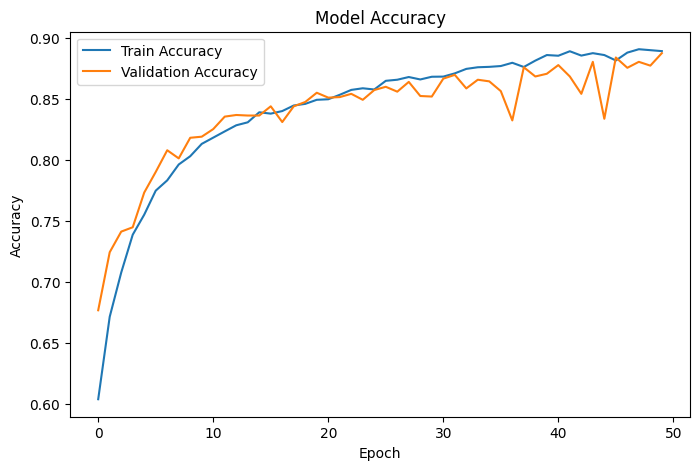

In [40]:
plt.figure(figsize=(8,5))
plt.plot(history.history['accuracy'])
plt.plot(history.history['val_accuracy'])
plt.title('Model Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend(['Train Accuracy', 'Validation Accuracy'])
plt.show()


In [ ]:
X_scale=scaler.transform(X_scale)